# 05 — Refinamento iterativo com pesos compartilhados (SAITS-2P)

**Motivação (evidência do notebook 04).** A adaptação do SAITS (DMSA + perda conjunta
MIT+ORT, bloco único) superou o BERT nos 6 cenários, mas o gargalo continua sendo a
imputação de **blocos** (MAE ~0,18 vs ~0,14 pontual), onde o RMSE até piorou levemente.
O diagnóstico do token espectral mostrou que informação *global* é redundante — o que
falta a uma posição no fundo de um bloco longo não é o espectro da janela, e sim
**âncoras locais**: seus vizinhos entram na atenção como `[0, flag de máscara]`, quase
sem conteúdo.

**Método.** Refinamento iterativo com pesos compartilhados (`n_passadas=2` no
`SAITSFFT`, sem token espectral): a 1ª passada imputa; as lacunas são preenchidas com
essas imputações (eq. 13 do SAITS) e o **mesmo** encoder roda de novo, agora vendo
valores plausíveis como âncoras — o canal de máscara segue marcando o que era lacuna
original. É o mecanismo do 2º bloco DMSA do SAITS com **zero parâmetros novos**
(profundidade por iteração, não por parâmetros — 150.337 parâmetros, idêntico à
variante de 1 passada). Treino end-to-end com supervisão nas duas passadas
(`perda_mit_ort_passadas`, análoga à perda acumulada da eq. 21 do SAITS); custo por
época ~2× (inerente ao método), mesmo nº de épocas, dados e sementes.

**Desenho experimental.** A ablação do refinamento é a variante de 1 passada — que é
exatamente o checkpoint `resultados/saits_base/` do notebook 04 (nada a retreinar).
Avaliamos os 4 modelos + baselines no protocolo dos notebooks 03/04 (máscaras semente
123, 6 cenários). Novos artefatos: `resultados/saits_refino/` e
`resultados/metricas_refino.{csv,json}`; nada anterior é sobrescrito.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))
from src import dados
from src.estilo import aplicar_estilo, PALETA, TINTA_2, DESTAQUE_MASCARA
from src.saits_fft import SAITSFFT, carregar_saits
from src.treino import treinar, fixar_semente, perda_mit_ort_passadas, carregar_modelo
from src.avaliacao import avaliar_metodos, imputar_bert_lotes
from src.mascaramento import mascaras_avaliacao, trechos_mascarados

aplicar_estilo()

device = "cuda" if torch.cuda.is_available() else "cpu"
arrays, stats, cfg_dados = dados.carregar_processado("dados_processados")
ds_treino = dados.JanelasDataset(arrays["treino"])
ds_val = dados.JanelasDataset(arrays["val"])
print(f"device: {device}  |  janelas de treino: {len(ds_treino):,}  |  validação: {len(ds_val):,}")

device: cuda  |  janelas de treino: 72,500  |  validação: 2,500


In [2]:
CFG = {
    "semente": 42,
    "epocas": 40,
    "batch": 256,
    "lr": 1e-3,
    "paciencia": 6,          # early stopping
    "mascara": {"razao": 0.25, "prob_bloco": 0.5, "lm": 6.0},
    "modelo": {"seq_len": 168, "d_model": 64, "n_camadas": 3, "n_cabecas": 4,
               "d_ff": 256, "dropout": 0.1, "usar_fft": False, "n_passadas": 2},
}

def n_parametros(m):
    return sum(p.numel() for p in m.parameters())

n_1p = n_parametros(SAITSFFT(**{**CFG["modelo"], "n_passadas": 1}))
n_2p = n_parametros(SAITSFFT(**CFG["modelo"]))
print(f"SAITS 1 passada : {n_1p:,} parâmetros")
print(f"SAITS-2P        : {n_2p:,} parâmetros (pesos compartilhados → idêntico)")
assert n_1p == n_2p

SAITS 1 passada : 150,337 parâmetros
SAITS-2P        : 150,337 parâmetros (pesos compartilhados → idêntico)


C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Treinamento

A validação/early stopping mede o MSE nas posições mascaradas da **saída final** (em
modo avaliação o forward devolve só a última passada), então a curva é diretamente
comparável às dos notebooks 02 e 04. A perda de treino impressa é a média das duas
passadas (MIT+ORT em cada), por isso seu valor absoluto não é comparável ao dos treinos
anteriores — a curva de validação é.

In [3]:
%%time
fixar_semente(CFG["semente"])
saits_2p = SAITSFFT(**CFG["modelo"])
hist_2p = treinar(saits_2p, ds_treino, ds_val, CFG, device,
                  "resultados/saits_refino", fn_perda=perda_mit_ort_passadas)

época   1 | treino 0.4254 | val 0.1879  <- melhor


época   2 | treino 0.1562 | val 0.1000  <- melhor


época   3 | treino 0.1180 | val 0.0863  <- melhor


época   4 | treino 0.1057 | val 0.0786  <- melhor


época   5 | treino 0.0981 | val 0.0749  <- melhor


...

época  35 | treino 0.0647 | val 0.0574


época  36 | treino 0.0636 | val 0.0570


época  37 | treino 0.0650 | val 0.0570


época  38 | treino 0.0647 | val 0.0566


época  39 | treino 0.0637 | val 0.0568
early stopping (sem melhora há 6 épocas)
CPU times: total: 29min 34s
Wall time: 28min 54s


BERT (proposto)          melhor val (MIT): 0.0583  (época 40)
SAITS (DMSA+ORT)         melhor val (MIT): 0.0593  (época 37)
SAITS-FFT (proposto)     melhor val (MIT): 0.0592  (época 40)
SAITS-2P (refinamento)   melhor val (MIT): 0.0565  (época 33)


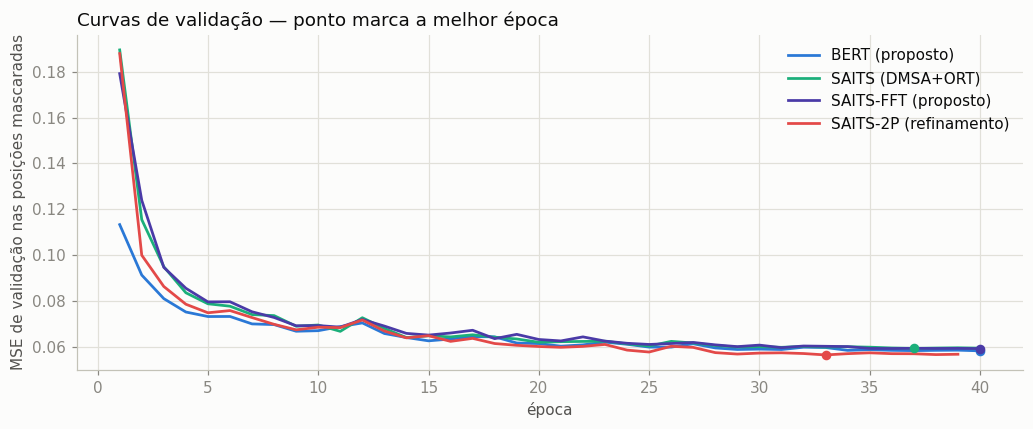

In [4]:
# curvas de validação (MSE só nas posições mascaradas, saída final → comparáveis)
CORES_MODELOS = {
    "BERT (proposto)": PALETA["azul"],
    "SAITS (DMSA+ORT)": PALETA["verde_agua"],
    "SAITS-2P (refinamento)": PALETA["vermelho"],
    "SAITS-FFT (proposto)": PALETA["violeta"],
}
historicos = {}
for nome, arq in [("BERT (proposto)", "resultados/historico.json"),
                  ("SAITS (DMSA+ORT)", "resultados/saits_base/historico.json"),
                  ("SAITS-FFT (proposto)", "resultados/saits_fft/historico.json")]:
    with open(arq, encoding="utf-8") as f:
        historicos[nome] = json.load(f)
historicos["SAITS-2P (refinamento)"] = hist_2p

fig, eixo = plt.subplots(figsize=(9.5, 4))
for nome, hist in historicos.items():
    val = [h["perda_val"] for h in hist]
    eixo.plot(range(1, len(val) + 1), val, color=CORES_MODELOS[nome], label=nome)
    melhor = int(np.argmin(val))
    eixo.scatter(melhor + 1, val[melhor], s=28, color=CORES_MODELOS[nome], zorder=3)
    print(f"{nome:24s} melhor val (MIT): {min(val):.4f}  (época {melhor + 1})")
eixo.set_xlabel("época")
eixo.set_ylabel("MSE de validação nas posições mascaradas")
eixo.set_title("Curvas de validação — ponto marca a melhor época", loc="left")
eixo.legend()
fig.tight_layout()
plt.show()

## Avaliação no conjunto de teste

Protocolo dos notebooks 03/04: máscaras determinísticas (semente 123), 6 cenários,
métricas apenas nas posições mascaradas. Os checkpoints do BERT e das variantes do
notebook 04 entram como estão.

In [5]:
%%time
j_teste, id_teste = arrays["teste"], arrays["id_teste"]
desvios = stats["desvio"].to_numpy()[id_teste].astype("float32")
medias = stats["media"].to_numpy()[id_teste].astype("float32")

modelos = {
    "BERT (proposto)": carregar_modelo("resultados/melhor_modelo.pt", device),
    "SAITS (DMSA+ORT)": carregar_saits("resultados/saits_base/melhor_modelo.pt", device),
    "SAITS-2P (refinamento)": carregar_saits("resultados/saits_refino/melhor_modelo.pt", device),
    "SAITS-FFT (proposto)": carregar_saits("resultados/saits_fft/melhor_modelo.pt", device),
}

cenarios = [
    (f"{tipo} {int(razao*100)}%", tipo, razao)
    for tipo in ("pontual", "bloco")
    for razao in (0.10, 0.25, 0.50)
]
resultados = avaliar_metodos(
    j_teste, modelos, device, cenarios,
    semente=123, desvios=desvios, medias=medias,
)
resultados.to_csv("resultados/metricas_refino.csv", index=False)
resultados.to_json("resultados/metricas_refino.json", orient="records",
                   indent=2, force_ascii=False)
resultados.round(4)

C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


CPU times: total: 49.1 s
Wall time: 24.2 s


,cenário,método,MAE,RMSE,MAE_kW,RMSE_kW,MRE
0,pontual 10%,BERT (proposto),0.1315,0.2067,14.9422,47.6717,0.0446
1,pontual 10%,SAITS (DMSA+ORT),0.1274,0.2024,14.0864,45.6174,0.0421
2,pontual 10%,SAITS-2P (refinamento),0.1279,0.2058,14.1006,47.3318,0.0421
3,pontual 10%,SAITS-FFT (proposto),0.1324,0.2086,14.9058,47.8461,0.0445
4,pontual 10%,média da janela,0.7789,0.9239,106.8868,308.9570,0.3194
5,pontual 10%,último valor (ffill),0.2929,0.4686,35.6964,145.3564,0.1067
6,pontual 10%,interpolação linear,0.1841,0.2884,21.5006,78.1609,0.0642
7,pontual 25%,BERT (proposto),0.1373,0.2114,15.3225,47.0040,0.0459
8,pontual 25%,SAITS (DMSA+ORT),0.1335,0.2077,14.7446,46.1952,0.0441
9,pontual 25%,SAITS-2P (refinamento),0.1330,0.2086,14.5658,46.2811,0.0436


In [6]:
# MAE por cenário e deltas do refinamento
nomes_cen = [c[0] for c in cenarios]
tabela_mae = resultados.pivot(index="cenário", columns="método", values="MAE").loc[nomes_cen]
comparacao = tabela_mae[list(modelos)].copy()
comparacao["Δ% 2P vs BERT"] = (
    100 * (comparacao["SAITS-2P (refinamento)"] - comparacao["BERT (proposto)"])
    / comparacao["BERT (proposto)"]
)
comparacao["Δ% 2P vs 1 passada"] = (
    100 * (comparacao["SAITS-2P (refinamento)"] - comparacao["SAITS (DMSA+ORT)"])
    / comparacao["SAITS (DMSA+ORT)"]
)
comparacao.round(4)

método,BERT (proposto),SAITS (DMSA+ORT),SAITS-2P (refinamento),SAITS-FFT (proposto),Δ% 2P vs BERT,Δ% 2P vs 1 passada
cenário,,,,,,
pontual 10%,0.1315,0.1274,0.1279,0.1324,-2.7018,0.4650
pontual 25%,0.1373,0.1335,0.1330,0.1370,-3.0887,-0.3536
pontual 50%,0.1558,0.1522,0.1487,0.1573,-4.5614,-2.3061
bloco 10%,0.1727,0.1722,0.1718,0.1749,-0.5155,-0.2404
bloco 25%,0.1756,0.1755,0.1737,0.1771,-1.0782,-1.0040
bloco 50%,0.1877,0.1873,0.1831,0.1903,-2.4145,-2.2165


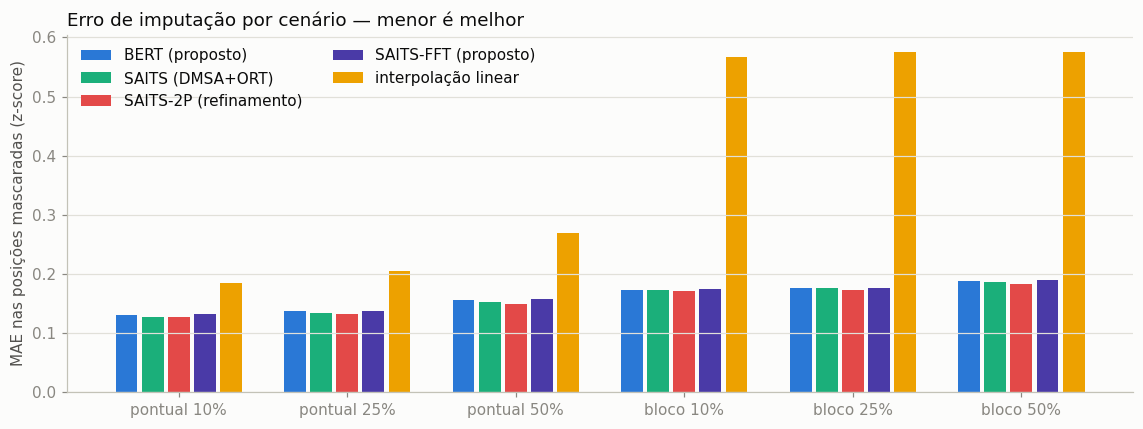

In [7]:
# barras agrupadas: 4 modelos + melhor baseline como referência
ordem = ["BERT (proposto)", "SAITS (DMSA+ORT)", "SAITS-2P (refinamento)",
         "SAITS-FFT (proposto)", "interpolação linear"]
cores = {**CORES_MODELOS, "interpolação linear": PALETA["amarelo"]}
x = np.arange(len(nomes_cen))
larg = 0.155

fig, eixo = plt.subplots(figsize=(10.5, 4))
for k, met in enumerate(ordem):
    v = tabela_mae.loc[nomes_cen, met].to_numpy()
    eixo.bar(x + (k - 2) * larg, v, width=larg - 0.025, color=cores[met], label=met)
eixo.set_xticks(x)
eixo.set_xticklabels(nomes_cen)
eixo.set_ylabel("MAE nas posições mascaradas (z-score)")
eixo.set_title("Erro de imputação por cenário — menor é melhor", loc="left")
eixo.legend(ncols=2, loc="upper left")
eixo.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## Diagnóstico: a 2ª passada melhora a 1ª?

Comparamos o MAE da reconstrução de **cada passada** do modelo treinado. Se o
refinamento funciona, a 2ª passada deve ser melhor que a 1ª — e a diferença deve se
concentrar nos blocos, onde as âncoras preenchidas importam mais.

In [8]:
modelo_2p = modelos["SAITS-2P (refinamento)"]
x_teste = torch.from_numpy(np.ascontiguousarray(j_teste, dtype="float32"))

def mae_por_passada(cenario, razao, batch=256):
    masc_d = mascaras_avaliacao(len(x_teste), x_teste.shape[1], cenario, razao, semente=123)
    p1, p2 = [], []
    for i in range(0, len(x_teste), batch):
        rs = modelo_2p.reconstruir_passadas(
            x_teste[i:i + batch].to(device), masc_d[i:i + batch].to(device))
        p1.append(rs[0].cpu())
        p2.append(rs[1].cpu())
    p1, p2 = torch.cat(p1), torch.cat(p2)
    return ((p1 - x_teste)[masc_d].abs().mean().item(),
            (p2 - x_teste)[masc_d].abs().mean().item())

linhas_diag = {}
for nome_c, tipo, razao in cenarios:
    m1, m2 = mae_por_passada(tipo, razao)
    linhas_diag[nome_c] = {"passada 1": m1, "passada 2 (final)": m2,
                           "Δ% da 2ª passada": 100 * (m2 - m1) / m1}
diag_passadas = pd.DataFrame(linhas_diag).T
diag_passadas.index.name = "cenário"
diag_passadas.to_json("resultados/saits_refino/diagnostico_passadas.json",
                      orient="index", indent=2, force_ascii=False)
diag_passadas.round(4)

,passada 1,passada 2 (final),Δ% da 2ª passada
cenário,,,
pontual 10%,0.1262,0.1279,1.4043
pontual 25%,0.1347,0.1330,-1.2185
pontual 50%,0.1543,0.1487,-3.6252
bloco 10%,0.1720,0.1718,-0.1526
bloco 25%,0.1747,0.1737,-0.5287
bloco 50%,0.1874,0.1831,-2.2523


## Exemplo qualitativo

Mesma janela e máscara de bloco 50 % do notebook 04, agora comparando a variante de
1 passada com o refinamento (faixas cinzas = trechos escondidos dos modelos).

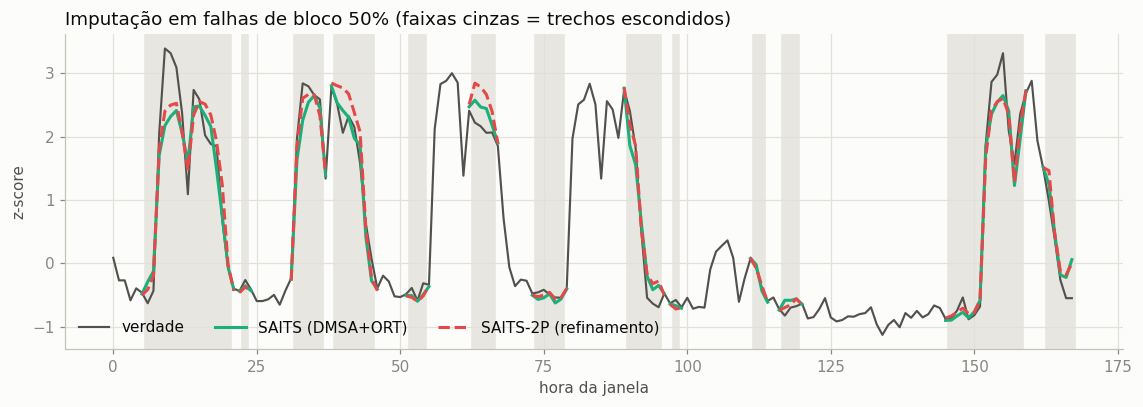

In [9]:
idx_exemplo = 17
x_ex = torch.from_numpy(j_teste[idx_exemplo : idx_exemplo + 1])
masc = mascaras_avaliacao(1, x_ex.shape[1], "bloco", 0.50, semente=7)
imput_1p = imputar_bert_lotes(modelos["SAITS (DMSA+ORT)"], x_ex, masc, device)[0].numpy()
imput_2p = imputar_bert_lotes(modelos["SAITS-2P (refinamento)"], x_ex, masc, device)[0].numpy()

m = masc[0].numpy()
t = np.arange(x_ex.shape[1])
fig, eixo = plt.subplots(figsize=(10.5, 3.8))
for ini, fim in trechos_mascarados(m):
    eixo.axvspan(ini - 0.5, fim - 0.5, color=DESTAQUE_MASCARA, zorder=0)
eixo.plot(t, x_ex[0], color=TINTA_2, linewidth=1.4, label="verdade")
primeiro = trechos_mascarados(m)[0][0]
for ini, fim in trechos_mascarados(m):
    tr = slice(max(ini - 1, 0), min(fim + 1, len(t)))
    eixo.plot(t[tr], imput_1p[tr], color=PALETA["verde_agua"], linewidth=2.0,
              label="SAITS (DMSA+ORT)" if ini == primeiro else None)
    eixo.plot(t[tr], imput_2p[tr], color=PALETA["vermelho"], linewidth=2.0, linestyle="--",
              label="SAITS-2P (refinamento)" if ini == primeiro else None)
eixo.set_xlabel("hora da janela")
eixo.set_ylabel("z-score")
eixo.set_title("Imputação em falhas de bloco 50% (faixas cinzas = trechos escondidos)", loc="left")
eixo.legend(ncols=3)
fig.tight_layout()
plt.show()

In [10]:
# resumo: média por tipo de cenário e ganho relativo do refinamento
resumo = []
for tipo in ("pontual", "bloco"):
    sel = [c for c in nomes_cen if c.startswith(tipo)]
    linha = {"tipo": tipo}
    for met in modelos:
        linha[met] = tabela_mae.loc[sel, met].mean()
    linha["Δ% 2P vs BERT"] = 100 * (linha["SAITS-2P (refinamento)"] - linha["BERT (proposto)"]) / linha["BERT (proposto)"]
    linha["Δ% 2P vs 1 passada"] = 100 * (linha["SAITS-2P (refinamento)"] - linha["SAITS (DMSA+ORT)"]) / linha["SAITS (DMSA+ORT)"]
    resumo.append(linha)
resumo = pd.DataFrame(resumo).set_index("tipo")
resumo.round(4)

,BERT (proposto),SAITS (DMSA+ORT),SAITS-2P (refinamento),SAITS-FFT (proposto),Δ% 2P vs BERT,Δ% 2P vs 1 passada
tipo,,,,,,
pontual,0.1415,0.1377,0.1366,0.1422,-3.5093,-0.8207
bloco,0.1787,0.1783,0.1762,0.1807,-1.3648,-1.1827


## Conclusões

**O refinamento funcionou: o SAITS-2P é o melhor modelo do trabalho.**

- **MAE**: menor que o do BERT nos 6 cenários (−0,5 % a −4,6 %; média pontual −3,5 %,
  média bloco −1,4 %) e menor que o da ablação de 1 passada em 5 de 6 (única exceção:
  pontual 10 %, +0,5 %). Os ganhos sobre a 1 passada se concentram exatamente onde a
  hipótese previa — os cenários com menos âncoras locais: pontual 50 % (−2,3 %) e
  bloco 50 % (−2,2 %).
- **RMSE**: menor que o do BERT nos 6 cenários — e corrige a regressão nos blocos que a
  variante de 1 passada apresentava (bloco 50 %: 0,2932 vs 0,2977 do BERT vs 0,3002 da
  1 passada). Também lidera em MAE_kW e MRE em 5 dos 6 cenários.
- **Validação**: 0,0565, a melhor de todos (BERT 0,0583; 1 passada 0,0593; FFT 0,0592),
  com early stopping na época 33/39.
- **Custo**: zero parâmetros novos (150.337, idênticos à 1 passada); ~2× o tempo por
  época (29 min de treino total) e ~2× o custo de inferência.

**O diagnóstico confirma o mecanismo.** A 2ª passada melhora a própria 1ª exatamente
nos cenários difíceis (pontual 50 %: −3,6 %; bloco 50 %: −2,3 %) e não ajuda onde o
contexto observado já é denso (pontual 10 %: +1,4 %) — consistente com a explicação de
que o ganho vem das âncoras preenchidas nas lacunas. Curiosamente, a própria 1ª passada
do modelo refinado já supera a variante dedicada de 1 passada em vários cenários: a
supervisão profunda melhora o encoder em si.

**Leitura para a contribuição.** Combinando os notebooks 04 e 05, a contribuição
composta do trabalho fica: **adaptação simplificada do SAITS (bloco DMSA único + perda
conjunta MIT+ORT) com refinamento iterativo de pesos compartilhados** — recupera o
benefício do 2º bloco do SAITS por *iteração* em vez de *parâmetros*, e supera o BERT
em MAE e RMSE em todos os 6 cenários com o mesmo número de parâmetros. O token
espectral [FREQ] permanece documentado como ablação com resultado negativo explicado
(notebook 04).

**Ressalvas.** Uma única semente (42); os ganhos de 1–5 % pedem repetição com múltiplas
sementes para intervalos de confiança. As máscaras de avaliação determinísticas
(semente 123) tornam os números exatamente reprodutíveis.

**Artefatos gerados** (nada anterior foi sobrescrito): `resultados/saits_refino/`
(checkpoint, histórico e `diagnostico_passadas.json`) e
`resultados/metricas_refino.{csv,json}`.